In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
"""
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))


"""

def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))

    positions = np.arange(seq_len)[:, np.newaxis]

    dimensions = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(
        10000,
        (2 * (dimensions // 2)) / d_model
    )

    angles = positions * angle_rates

    # Even dimensions  sine
    PE[:, 0::2] = np.sin(angles[:, 0::2])

    # Odd dimensions  cosine
    PE[:, 1::2] = np.cos(angles[:, 1::2])

    return PE

In [3]:
sentence_1 = "The cat chased the mouse"
sentence_2 = "The mouse chased the cat"

tokens_1 = sentence_1.lower().split()
tokens_2 = sentence_2.lower().split()
print("Scantance1:",sentence_1)
print("Scantance2:",sentence_2)

Scantance1: The cat chased the mouse
Scantance2: The mouse chased the cat


In [4]:
# Generate positional encoding

d_model = 8

PE_1 = positional_encoding(
    seq_len=len(tokens_1),
    d_model=d_model
)

PE_2 = positional_encoding(
    seq_len=len(tokens_2),
    d_model=d_model
)

for position, token in enumerate(tokens_1):
    print(f"Sentence 1 Position {position}: {token}")

for position, token in enumerate(tokens_2):
    print(f"Sentence 2 Position {position}: {token}")

Sentence 1 Position 0: the
Sentence 1 Position 1: cat
Sentence 1 Position 2: chased
Sentence 1 Position 3: the
Sentence 1 Position 4: mouse
Sentence 2 Position 0: the
Sentence 2 Position 1: mouse
Sentence 2 Position 2: chased
Sentence 2 Position 3: the
Sentence 2 Position 4: cat


In [5]:
print("Positional Encoding for Sentence 1:")
print(np.round(PE_1, 3))

print("Positional Encoding for Sentence 2:")
print(np.round(PE_2, 3))

Positional Encoding for Sentence 1:
[[ 0.     1.     0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.54   0.1    0.995  0.01   1.     0.001  1.   ]
 [ 0.909 -0.416  0.199  0.98   0.02   1.     0.002  1.   ]
 [ 0.141 -0.99   0.296  0.955  0.03   1.     0.003  1.   ]
 [-0.757 -0.654  0.389  0.921  0.04   0.999  0.004  1.   ]]
Positional Encoding for Sentence 2:
[[ 0.     1.     0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.54   0.1    0.995  0.01   1.     0.001  1.   ]
 [ 0.909 -0.416  0.199  0.98   0.02   1.     0.002  1.   ]
 [ 0.141 -0.99   0.296  0.955  0.03   1.     0.003  1.   ]
 [-0.757 -0.654  0.389  0.921  0.04   0.999  0.004  1.   ]]


In [11]:
# cat_position_1 = tokens_1.index("cat")

cat_position_1 = tokens_1.index("cat")
cat_position_2 = tokens_2.index("cat")

mouse_position_1 = tokens_1.index("mouse")
mouse_position_2 = tokens_2.index("mouse")

print(
    f"'cat'    Sentence 1: Position {cat_position_1}, "
    f"Sentence 2: Position {cat_position_2}"
)

print(
    f"'mouse'  Sentence 1: Position {mouse_position_1}, "
    f"Sentence 2: Position {mouse_position_2}"
)

'cat'    Sentence 1: Position 1, Sentence 2: Position 4
'mouse'  Sentence 1: Position 4, Sentence 2: Position 1


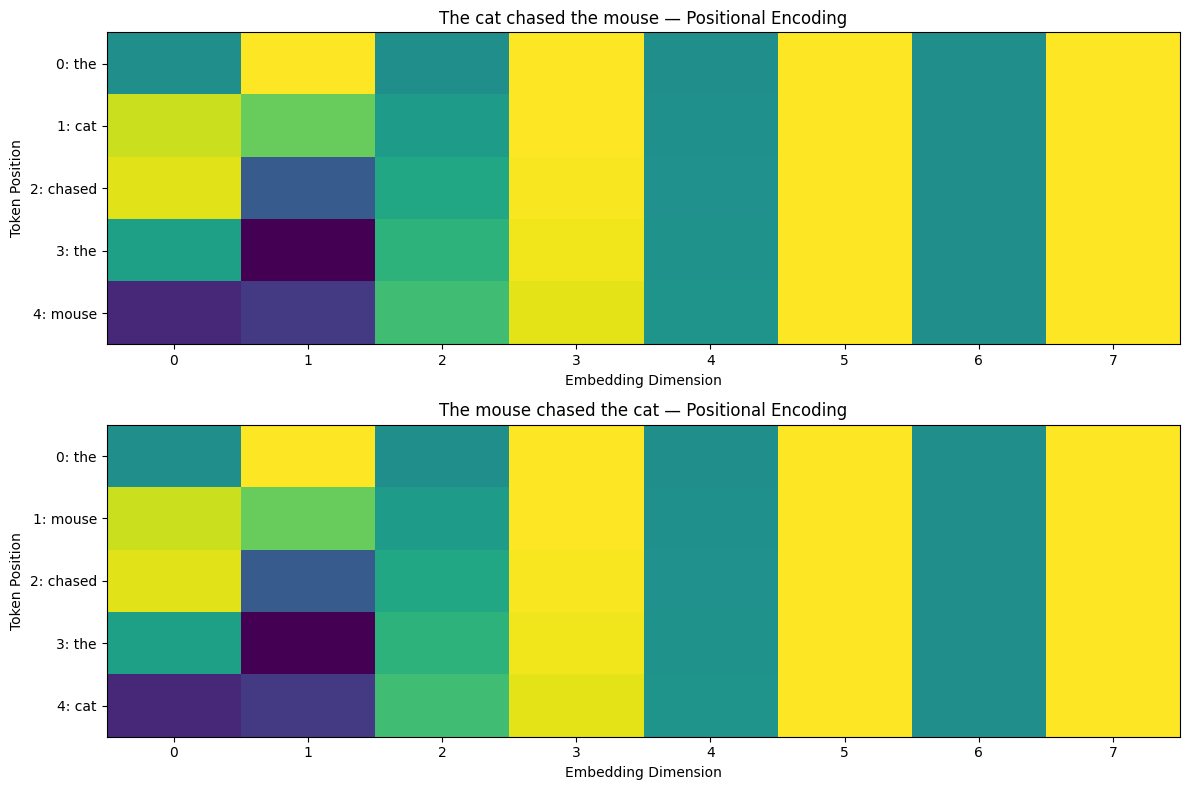

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Sentence 1
axes[0].imshow(PE_1, aspect="auto")
axes[0].set_title("The cat chased the mouse — Positional Encoding")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Token Position")

axes[0].set_yticks(range(len(tokens_1)))
axes[0].set_yticklabels([f"{i}: {token}" for i, token in enumerate(tokens_1)])


# Sentence 2
axes[1].imshow(PE_2, aspect="auto")
axes[1].set_title("The mouse chased the cat — Positional Encoding")
axes[1].set_xlabel("Embedding Dimension")
axes[1].set_ylabel("Token Position")

axes[1].set_yticks(range(len(tokens_2)))
axes[1].set_yticklabels([f"{i}: {token}" for i, token in enumerate(tokens_2)])

plt.tight_layout()
plt.show()
